<tabel>
 <tr align=left><td><img align=left src="https://i.creativecommons.org/l/by/4.0/88x31.png">
 <td>Teks disediakan di bawah lisensi Creative Commons Attribution, CC-BY. Semua kode tersedia di bawah lisensi MIT yang disetujui FSF. (c) Kyle T. Mandli</td>
</tabel>

In [ ]:
from __future__ import print_function
%matplotlib inline
import numpy
import matplotlib.pyplot as plt

# Persamaan Campuran

Kami sekarang mengeksplorasi bagaimana kami dapat menggunakan metode yang telah kami analisis dan kembangkan untuk menyelesaikan persamaan yang lebih kompleks yang tidak mudah masuk dalam salah satu klasifikasi PDE yang telah kami pelajari.

Kami akan fokus di sini pada formulir PDE
 $$
    u_t = \mathcal{A}_1(u) + \mathcal{A}_2(u) + \cdots + \mathcal{A}_N(u)
$$ 
dimana $\mathcal{A}_j(u)$ adalah fungsi dari $u$ dan turunannya (juga mungkin non-linier).

Karena sebagian besar metode yang akan kita bahas dapat digeneralisasikan dari kasus hanya dua operator $\mathcal{A}_j$, kami akan memusatkan perhatian pada PDE
 $$
    u_t = \mathcal{A}(u) + \mathcal{B}(u).
$$ 
Sekarang mari kita perhatikan beberapa contoh persamaan jenis ini.

### Contoh - Masalah Multidimensi

Kita telah melihat bagaimana kita dapat mendekati permasalahan multidimensi yang digabungkan dengan turunan waktu.  Ini juga dianggap campuran dan banyak metode yang akan kita pertimbangkan dapat diterapkan pada masalah multidimensi seperti persamaan panas
 $$
    u_t = \kappa(u_{xx} + u_{yy})
$$ 
atau PDE hiperbolik multidimensi
 $$
    u_t + f(u)_x + g(u)_y = 0.
$$

### Contoh - Persamaan Difusi Reaksi

Kita dapat menambahkan suku lain pada persamaan kalor yang sering kali mewakili suku reaksi kimia (terkadang juga disebut suku sumber atau sinkronisasi) sehingga kita memperoleh
 $$
    u_t = \kappa u_{xx} + R(u).
$$ 
Kita mungkin ingin menangani istilah $R(u)$ secara berbeda dari istilah difusi jika istilah tersebut memiliki skala temporal yang berbeda, mungkin tidak kaku, atau sulit diselesaikan jika digabungkan dengan pendekatan kita terhadap persamaan panas.

### Contoh - Persamaan Adveksi-Difusi

Kita juga telah melihat kasus ketika mempertimbangkan metode numerik untuk adveksi dimana persamaan yang dimodifikasi dapat mewakili sistem difusi adveksi dalam bentuk
 $$
    u_t + a u_x = \kappa u_{xx}.
$$

Ternyata persamaan jenis ini jauh lebih lazim dari sekedar persamaan ini, faktanya persamaan Navier-Stokes adalah contoh himpunan persamaan difusi adveksi yang dibatasi (dibatasi karena tidak dapat dimampatkan).  Kami juga menemukan persamaan hiperbolik nonlinier dengan suku kental seperti
 $$
    u_t + f(u)_x = \kappa u_{xx}
$$ 
menjadi hal yang umum ketika memperkirakan dinamika fluida secara umum.  Persamaan Burger kental
 $$
    u_t + u u_x = \epsilon u_{xx}
$$ 
adalah contoh lain.

### Contoh - Persamaan Adveksi-Difusi-Reaksi

Mengapa tidak menggabungkan semua hal di atas?
 $$
    u_t + f(u)_x = \kappa u_{xx} + R(u)
$$ 
Persamaan jenis ini umum terjadi pada kasus aliran fluida reaktif.  Pemodelan pembakaran misalnya biasanya melibatkan 10-100 suku reaksi yang berbeda dengan skala waktu yang sangat berbeda sehingga menjadikan permasalahan ini sangat sulit untuk dipecahkan.

### Contoh - Adveksi-Dispersi

Kami juga melihat persamaan yang dimodifikasi dalam penelitian kami tentang PDE hiperbolik yang berisi istilah advektif dan dispersif.  Contoh lain dari persamaan jenis ini adalah persamaan Kortweg-de Vries (KdV).
 $$
    u_t + u u_x = \nu u_{xxx}.
$$ 
Persamaan ini dapat diturunkan dari persamaan Euler yang memodelkan aliran fluida tak termampatkan dan mewakili sejumlah fenomena menarik, terutama gelombang soliton.  Persamaan serupa adalah persamaan Schrödinger nonlinier
 $$
    i \Psi_t(x,t) = -\Psi_{xx}(x,t) + V(\Psi)
$$ 
dimana $V(\Psi)$ adalah potensi nonlinier.

### Contoh - Adveksi-Difusi-Dispersi-Hiperdiffusi-...

Persamaan Kuramoto-Sivashinsky
 $$
    u_t + \frac{1}{2} (u_x)^2 = -u_{xx} - u_{xxxx}
$$ 
adalah persamaan menarik lainnya.  Tampaknya tidak tepat dan bahkan mungkin meledak karena tanda-tanda di depan difusi tetapi ternyata hal ini tidak terjadi dan redaman yang sesuai disediakan oleh istilah transportasi (sisi kanan) untuk menstabilkan persamaan.

## Metode Garis yang Digabungkan Sepenuhnya

Pendekatan pertama yang akan kita pelajari adalah pendekatan yang telah kita perkenalkan sebelumnya.  Kami berasumsi bahwa beberapa diskritisasi spasial diterapkan sepenuhnya pada semua istilah spasial yang mengarah pada sistem persamaan bentuk
 $$
    U'(t) = F(U(t)).
$$ 
Pendekatan ini dapat berhasil dan memberikan banyak fleksibilitas dalam hal urutan keakuratan dan stensil yang tersedia, namun dapat menimbulkan masalah jika beberapa istilah di sebelah kanan kaku sementara yang lain tidak.  Contoh terbaik dari hal ini adalah persamaan adveksi-difusi kecuali kekuatan relatif dari adveksi vs. difusi (disebut bilangan Peclet) sangat mendukung satu suku atau suku lainnya.

## Metode Deret Taylor yang Digabungkan Sepenuhnya

Kita juga dapat menggunakan deret Taylor untuk menyusun metode persamaan campuran.  Pertimbangkan ekspansi Taylor dalam waktu
 $$
    u(x, t + \Delta t) \approx u(x, t) + \Delta t u_t + \cdots,
$$ 
jika kita mengganti $u_t$ dengan sisi kanan kita membuat metodenya
 $$
    U^{n+1}_j = U^n_j + \Delta t (A(U^n_j) + B(U^n_j))
$$ 
dimana $A$ dan $B$ merupakan versi diskritisasi yang tepat dari $\mathcal{A}$ dan $\mathcal{B}$ .

Kita dapat memperluasnya ke tingkat yang lebih tinggi dengan mempertahankan lebih banyak suku dalam ekspansi Taylor.  Pertimbangkan PDE hiperbolik dua dimensi
 $$
    u_t + a u_x + b u_y = 0.
$$ 
Deret Taylor terpotong ke orde kedua adalah
 $$
    u(x, t + \Delta t) \approx u(x, t) + \Delta t u_t + \frac{\Delta t^2}{2} u_{tt} + \cdots,
$$ 
jadi kita perlu menghitung suku $u_{tt}$.

Mengambil turunan dari persamaan awal yang kita miliki
 $$\begin{aligned}
    u_{tt} &= -a u_{xt} - b u_{yt} \\
    &= -a (u_t)_x - b (u_t)_y \\
    &= -a (-a u_x - b u_y)_x - b (-a u_x - b u_y)_y \\
    &= a^2 u_{xx} + a b u_{yx} + a b u_{xy} + b^2 u_{yy} \\
    &= a^2 u_{xx} + 2 a b u_{xy} + b^2 u_{yy}.
\end{aligned}$$ 
Jika ini adalah sistem PDE hiperbolik $a$ dan $b$ akan menjadi matriks dan kita akan memiliki ekspresi yang sedikit berbeda
 $$
    u_{tt} = A^2 u_{xx} + (A B + B A) u_{xy} + B^2 u_{yy}.
$$

Ini mengarah pada metode tersebut
 $$
    U^{n+1}_{ij} = U^n_{ij} - \Delta t (A D_{x} U^n_{ij} + B D_{y} U^n_{ij}) + \frac{1}{2} \Delta t^2 (A^2 D^2_x U^n_{ij} + (A B + B A) D_x D_y U^n_{ij} + B^2 D^2_y U^n_{ij} )
$$ 
yang merupakan metode Lax-Wendroff dua dimensi jika pendekatan terpusat digunakan untuk mendiskritisasi turunannya dengan tepat.

## Metode Langkah Pecahan

Salah satu cara paling umum untuk menangani persamaan campuran adalah melalui metode langkah pecahan (alias metode pembagian waktu, langkah terpisah, atau pemisahan operator).

Intinya kami membagi masalah menjadi dua langkah, langkah pertama yang menyelesaikan istilah yang berhubungan dengan $\mathcal{A}$ dan langkah lainnya yang berhubungan dengan $\mathcal{B}$ :
 $$
    U^\ast = \mathcal{N}_A(U^n, \Delta t) \\
    U^{n+1} = \mathcal{N}_B(U^\ast, \Delta t)
$$ 
dimana $\mathcal{N}_{A}$ dan $\mathcal{N}_{B}$ mewakili metode numerik satu langkah untuk penyelesaian
 $$
    u_t = \mathcal{A}(u)
$$ 
dan
 $$
    u_t = \mathcal{B}(u)
$$ 
masing-masing.  Skema akurat orde pertama ini disebut *Pemisahan Godunov*.

Pendekatan ini memiliki keuntungan karena dapat menggunakan metode apa pun yang sesuai untuk masing-masing operator $\mathcal{A}$ dan $\mathcal{B}$ , misalnya metode eksplisit dan implisit.  Seperti yang disajikan di atas, namun pemisahan ini hanya akurat orde pertama meskipun konvergen seperti $\Delta t \rightarrow 0$ selama metode penyusunnya konvergen pada permasalahan masing-masing.  Dalam prakteknya kesalahan "pemisahan" kecil dibandingkan dengan diskritisasi langsung waktu dan ruang dan pendekatan ini bekerja dengan baik.

Masalah multidimensi juga dapat menggunakan pemisahan langkah pecahan seperti yang kita lihat sebelumnya.  Dalam konteks ini biasanya disebut *pemisahan dimensi* dan bisa sangat efektif pada pendekatan multidimensi sepenuhnya, terutama untuk dimensi yang lebih tinggi

### Analisis Kesalahan

Sekarang mari kita jelajahi jenis kesalahan apa yang terjadi karena kesalahan pemisahan kita.  Pertimbangkan ODE sederhana
 $$
    u_t = A u + B u
$$ 
dimana $A$ dan $B$ adalah matriks.

Karena kita mengetahui solusi dari ODE ini, kita dapat memilih kesalahan yang dihasilkan oleh pemisahan saja.  Ambil metode $\mathcal{N}$ dan setel ke solusi eksak persamaan split sehingga
 $$
    \mathcal{N}_A(U, \Delta t) = e^{A \Delta t} U
$$ 
dan
 $$
    \mathcal{N}_B(U, \Delta t) = e^{B \Delta t} U.
$$

Pendekatan langkah pecahan akan mengarah pada solusi
 $$\begin{aligned}
    U^\ast &= e^{A \Delta t} U^{n} \Rightarrow \\
    U^{n+1} &= e^{B\Delta t} U^\ast = e^{B\Delta t} e^{A \Delta t} U^{n}.
\end{aligned}$$ 
Intinya $e^{B\Delta t} e^{A \Delta t}$ memetakan kondisi awal di $t_n$ ke waktu baru $t_{n+1}$ (disebut operator solusi).

Solusi tepat untuk ODE asli juga
 $$
    u(t_n + \Delta t) = e^{(A + B) \Delta t} u(t_n)
$$ 
menunjukkan bahwa ada perbedaan dalam pendekatannya.

Taylor memperluas eksponensial matriks dari solusi eksak (operator solusi) yang kita lihat seharusnya kita miliki
 $$
    e^{(A + B) \Delta t} = I + \Delta t (A + B) + \frac{\Delta t^2}{2} (A+B)^2 + \cdots
$$ 
sementara Taylor memperluas eksponensial matriks dalam pendekatan langkah pecahan mengarah ke
 $$\begin{aligned}
    e^{B\Delta t} e^{A \Delta t} &= \left (I + \Delta t B + \frac{\Delta t^2}{2} B^2 + \cdots \right ) \left (I + \Delta t A + \frac{\Delta t^2}{2} A^2 + \cdots \right ) \\
    &= I + \Delta t (A + B) + \frac{\Delta t^2}{2} (A^2 + 2 B A + B^2) + \cdots.
\end{aligned}$$

Membandingkan dua ekspresi kita melihat bahwa rangkaian tersebut setara dengan $\mathcal{O}(\Delta t^2)$ di mana solusi sebenarnya memiliki
 $$
    (A + B)^2 = A^2 + A B + B A + B^2
$$ 
dimana perkiraannya adalah
 $$
    A^2 + 2 B A + B^2.
$$ 
Akibatnya, mengurangkan dua ekspresi untuk menemukan kesalahannya akan menyisakan hasil bagi kita 
 $$
    e^{(A + B) \Delta t} - e^{B \Delta t} e^{A \Delta t} = \tau^n = \frac{\Delta t^2}{2} (A B - B A)  + \mathcal{O}(\Delta t^3).
$$

Istilah di tengah ini sering disebut komutator dari operator $A$ dan $B$ yang dilambangkan dengan $[A, B] = A B - B A$ .  Jika komutatornya 0 maka pemisahannya akurat tingkat tinggi!  Perhatikan bahwa hal ini selalu berlaku ketika menyelesaikan persamaan skalar, dalam hal ini seluruh deret Taylor adalah identik dan kita menemukan bahwa tidak ada kesalahan yang disebabkan oleh pemisahan tersebut.

Kita juga dapat merumuskan metode orde kedua yang disebut *Pemisahan aneh* yang menggunakan
 $$
    U^\ast = \mathcal{A}(U^n, \Delta t / 2) \\
    U^{\ast\ast} = \mathcal{B}(U^\ast, \Delta t) \\
    U^{n+1} = \mathcal{A}(U^{\ast\ast}, \Delta t / 2).
$$ 
Berikut analisa diatas operator solusinya adalah
 $$
    e^{A \Delta t / 2} e^{B \Delta t} e^{A \Delta t /2}
$$ 
yang sesuai dengan deret Taylor eksak, apa pun deret Taylor hingga orde ketiga.

Hal ini mungkin tampak seperti pekerjaan yang berat, namun dalam praktiknya jika kita mengambil dua langkah, kita dapat menggabungkan dua evaluasi masing-masing metode untuk menunjukkan bahwa kecuali untuk langkah pertama, kita dapat mengganti langkah-langkah pada metode numerik:
 $$\begin{aligned}
    U^{n+3} &= \left (e^{A \Delta t / 2} e^{B \Delta t} e^{A \Delta t /2} \right)\left (e^{A \Delta t / 2} e^{B \Delta t} e^{A \Delta t /2} \right)\left (e^{A \Delta t / 2} e^{B \Delta t} e^{A \Delta t /2} \right) U^{n} \\
    &= e^{A \Delta t / 2} e^{B \Delta t} e^{A \Delta t} e^{B \Delta t} e^{A \Delta t} e^{B \Delta t} e^{A \Delta t /2}  U^{n}
\end{aligned}$$

Dalam pendekatan multidimensi terhadap persamaan kalor yang telah kita diskusikan yang berbentuk pemisahan Godunov, kami melihat bahwa persamaan tersebut sebenarnya akurat orde kedua.  Hanya untuk menyegarkan persamaannya
 $$
    u_t = u_{xx} + u_{yy}
$$ 
dengan $\mathcal{A} = u_{xx}$ dan $\mathcal{B} = u_{yy}$ .  Karena operator-operator ini melakukan perjalanan satu sama lain, kami melihat perkiraan akurat urutan kedua.

Namun pertimbangkan apa yang akan terjadi jika kita memiliki konstanta difusi yang bervariasi secara spasial sedemikian rupa
 $$
    u_t = (\kappa(x,y)u_x)_x + (\kappa(x,y)u_y)_y
$$ 
sehingga $\mathcal{A} = (\kappa(x,y)u_x)_x$ dan $\mathcal{B} = (\kappa(x,y)u_y)_y$ .  Ini tidak lagi bolak-balik dan metode yang dirumuskan hanya akurat secara formal.

Satu peringatan terakhir terhadap pemisahan fraksional adalah bahwa kondisi batas bisa jadi tidak mudah untuk diterapkan.  Hal ini muncul karena kebutuhan untuk menentukan kondisi batas pada tahap peralihan dan secara umum dapat menjadi masalah jika terdapat faktor yang bergantung pada waktu dalam persamaan karena waktu untuk mengevaluasi fungsi-fungsi ini pada tahap peralihan tidak jelas.

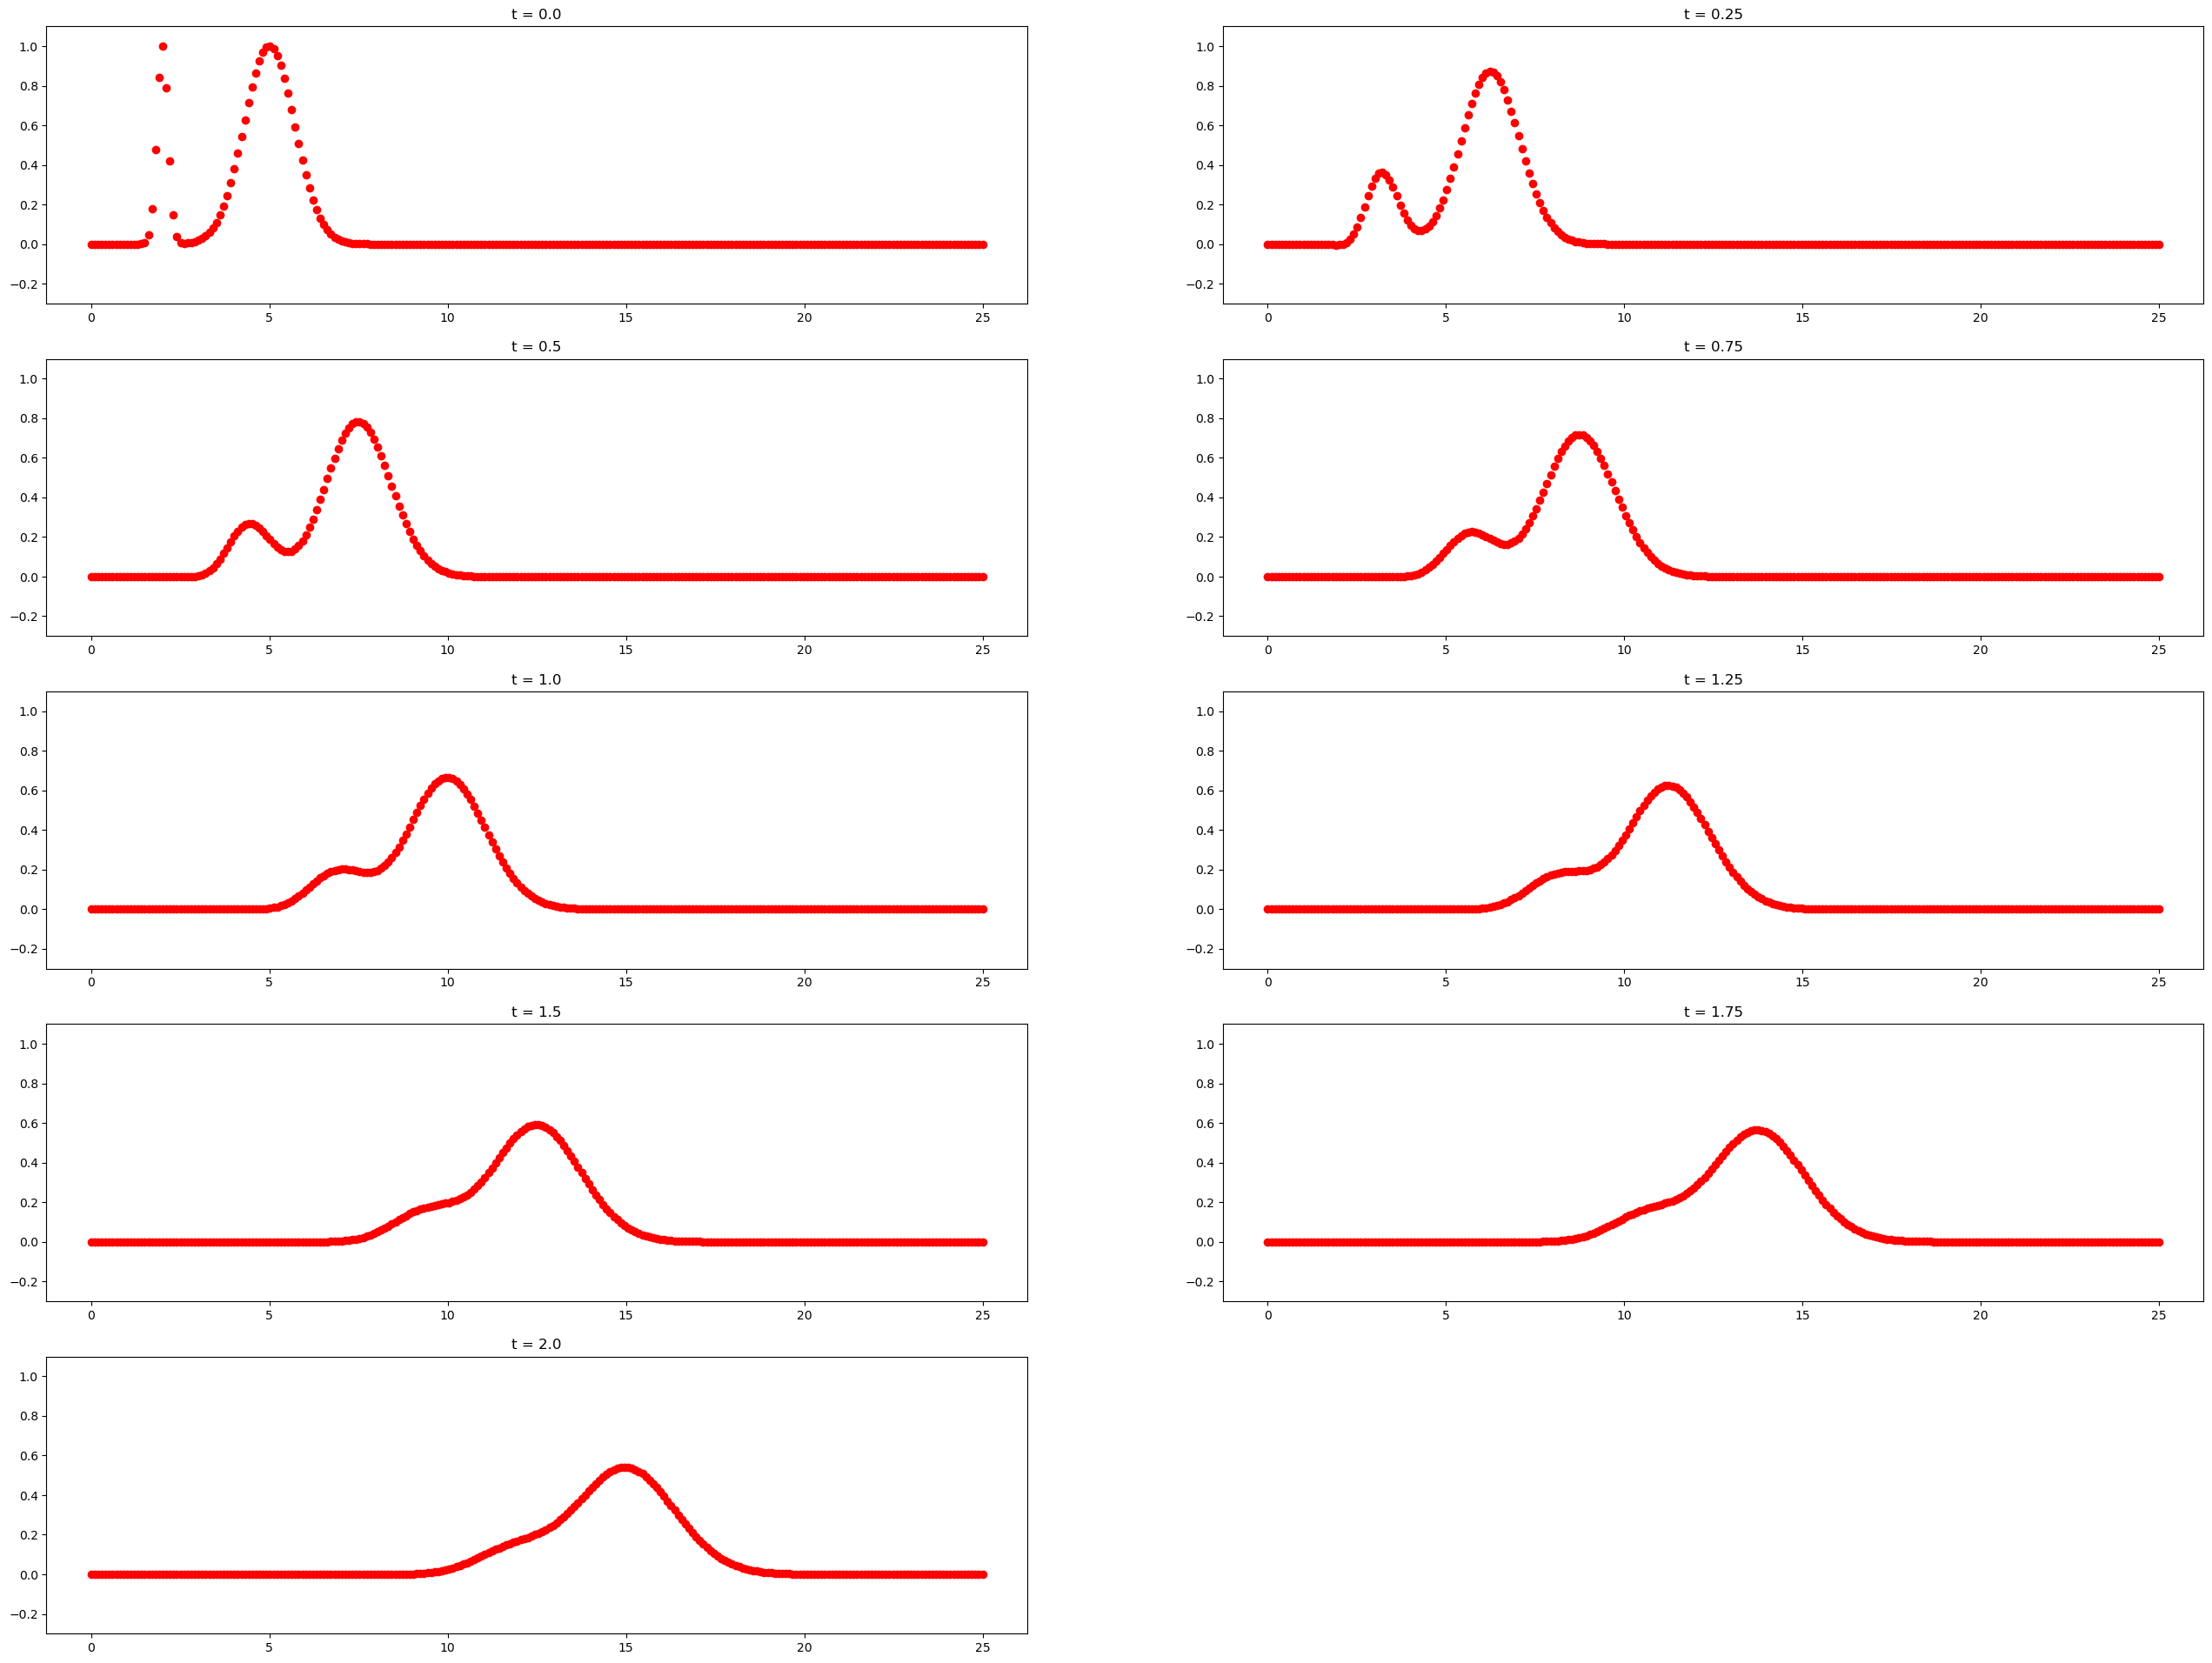

In [ ]:
import numpy
import matplotlib.pyplot as plt
import scipy.sparse as sparse
import scipy.sparse.linalg as linalg

def CN_step(delta_x, delta_t, t_0, U_0, kappa=1.0):
    
    # Membuat matriks sistem
    m = U_0.shape[0]  # jumlah grid
    r = 0.5 * kappa * delta_t / delta_x**2  # parameter skema Crank-Nicolson
    e = numpy.ones(m + 1) * r  # vektor bantu
    D2 = sparse.spdiags([e, -2.0 * e, e], [-1, 0, 1], m, m).tolil()  # matriks turunan kedua
    
    D2[0, -1] = r   # kondisi periodik (ujung kiri ke kanan)
    D2[-1, 0] = r   # kondisi periodik (ujung kanan ke kiri)
    
    I = sparse.eye(m)  # matriks identitas
    A1 = (I - D2).tocsr()  # matriks kiri sistem
    A2 = (I + D2).tolil()  # matriks kanan sistem
    
    # Membentuk ruas kanan
    b = A2.dot(U_0.copy())  # hasil perkalian matriks
    
    # Menyelesaikan sistem linear
    return linalg.spsolve(A1, b)  # solusi pada waktu berikutnya


def LW_step(delta_x, delta_t, t_0, U_0, a):
    """Menyelesaikan persamaan adveksi u_t + a u_x = 0"""
    
    U = numpy.empty(U_0.shape)  # array solusi baru
    
    # Titik pertama (dengan kondisi periodik)
    U[0] = U_0[0] - a * delta_t / (2.0 * delta_x) * (U_0[1] - U_0[-1]) \
                    + a * delta_t**2 / (2.0 * delta_x**2) * (U_0[1] - 2.0 * U_0[0] + U_0[-1])
    
    # Titik tengah
    U[1:-1] = U_0[1:-1] - a * delta_t / (2.0 * delta_x) * (U_0[2:] - U_0[:-2]) \
                          + a * delta_t**2 / (2.0 * delta_x**2) * (U_0[2:] - 2.0 * U_0[1:-1] + U_0[:-2])
    
    # Titik terakhir (kondisi periodik)
    U[-1] = U_0[-1] - a * delta_t / (2.0 * delta_x) * (U_0[0] - U_0[-2]) \
                      + a * delta_t**2 / (2.0 * delta_x**2) * (U_0[0] - 2.0 * U_0[-1] + U_0[-2])
    
    return U  # mengembalikan solusi baru


# Spesifikasi masalah
L = 25.0       # panjang domain
a = 5.0        # kecepatan adveksi
kappa = 0.5    # koefisien difusi

# Diskretisasi ruang
m = 250
x = numpy.linspace(0.0, L, m)  # grid ruang
delta_x = L / (m + 1.0)        # jarak antar titik

# Diskretisasi waktu
C = 1.0
delta_t = C * delta_x / a  # berdasarkan kondisi CFL

# Kondisi awal
U = numpy.exp(-20.0 * (x - 2.0)**2) + numpy.exp(-(x - 5.0)**2)  # fungsi awal

# Operator splitting (metode Godunov)
t = 0.0
TOLERANCE = 1e-8  # toleransi perbandingan waktu

# Waktu output yang diinginkan
output_times = [0.25, 0.5, 0.75, 1.0, 1.25, 1.5, 1.75, 2.0]

# Persiapan plotting
N = int(numpy.ceil((len(output_times) + 1) / 2.0))
fig = plt.figure()
fig.set_figwidth(fig.get_figwidth() * N)
fig.set_figheight(fig.get_figheight() * N)

# Plot kondisi awal
axes = fig.add_subplot(N, 2, 1)
axes.plot(x, U, 'ro')  # titik merah
axes.set_ylim((-0.3, 1.1))
axes.set_title("t = %s" % 0.0)

# Iterasi waktu
for (n, t_final) in enumerate(output_times):
    while t_final - t > TOLERANCE:
        
        # Langkah difusi (Crank-Nicolson)
        U = CN_step(delta_x, delta_t, t, U, kappa)
        
        # Langkah adveksi (Lax-Wendroff)
        U = LW_step(delta_x, delta_t, t, U, a)
        
        # Update waktu
        t += delta_t
        
        # Update delta_t berdasarkan CFL
        delta_t = min(delta_x / a, t_final - t)
    
    # Plot hasil pada waktu tertentu
    axes = fig.add_subplot(N, 2, n + 2)
    axes.plot(x, U, 'ro')
    axes.set_ylim((-0.3, 1.1))
    axes.set_title("t = %s" % t)

plt.show()  # menampilkan grafik

## Metode Implisit-Eksplisit (IMEX). 

Misalkan salah satu operator kita $\mathcal{A}(u)$ mewakili istilah kaku yang lebih kita sukai untuk diintegrasikan menggunakan metode implisit sementara $\mathcal{B}(u)$ tidak kaku dan kita ingin menerapkan metode eksplisit.  Daripada menggunakan metode langkah pecahan, kita dapat menggunakan metode *implisit-eksplisit* (IMEX).  Keuntungannya adalah keduanya digabungkan sepenuhnya (sehingga tidak ada kesalahan pemisahan) dan dirancang untuk dapat memilih istilah mana yang akan ditangani secara eksplisit dan mana yang implisit.

Salah satu contoh sederhananya adalah menggabungkan Euler mundur dan maju, mengevaluasi suku tidak kaku di $U^n$ dan suku kaku di $U^{n+1}$ untuk mencari
 $$
    U^{n+1} = U^n + \Delta t (\mathcal{A}(U^{n+1}) + \mathcal{B}(U^n)).
$$

Contoh lain yaitu orde kedua yang menggunakan Adams-Bashforth untuk komponen eksplisit dan aturan trapesium untuk implisit mengarah ke
 $$
    U^{n+1} = U^n + \frac{\Delta t}{2} \left(\mathcal{A}(U^n) + \mathcal{A}(U^{n+1}) + 3 \mathcal{B}(U^n) - \mathcal{B}(U^{n-1}) \right ).
$$

Secara umum kita dapat menggabungkan banyak metode yang telah kita pelajari untuk membentuk jenis metode ini termasuk metode multi-langkah seperti contoh sebelumnya dan metode multi-tahap seperti Runge-Kutta.

## Metode Perbedaan Waktu Eksponensial

Untuk metode terakhir kita akan mempertimbangkan ODE nonlinier umum
 $$
    u' = f(u)
$$ 
dan selama interval waktu $t \in [t_n, t_{n+1}]$ kami menulis ODE ini sebagai
 $$
    u'(t) = A_n u(t) + \mathcal{B}_n(u(t))
$$ 
di mana notasi kami menunjukkan bahwa $A_n$ adalah matriks dan oleh karena itu suku pertama linier sedangkan suku kedua mungkin tidak dan secara umum mengandung nonlinier dari ODE asli.

Ide dasar metode *perbedaan waktu eksponensial* (ETD) adalah menerapkan teknik solusi eksak (seperti prinsip Duhamel) untuk menangani bagian linier dan metode numerik untuk bagian nonlinier.  Seringkali kita membiarkan bagian linier berisi komponen persamaan yang kaku (seperti jika kita mendiskritisasi operator difusi) dan kemudian menggunakan metode eksplisit untuk menangani $\mathcal{B}_n$ .

Kita dapat mencapai pemisahan ini dengan dua cara umum:
1. Biarkan $A_n = f'(U^n)$ (Jacobian) lalu biarkan
 $$
    \mathcal{B}_n(u) = f(u) - A_n u.
$$ 
1. Jika kita mengetahui lebih banyak tentang struktur $f(u)$ kita dapat memanfaatkan strukturnya untuk membangun $A_n$ dan $\mathcal{B}_n$ .  Pertimbangkan misalnya jika kita mempunyai masalah difusi-adveksi, jika kita mendiskritisasikan hanya operator difusi dan mengaturnya ke $A_n$ dan membiarkan istilah adveksi (mungkin nonlinier) menjadi $\mathcal{B}$ .  Hal yang sama berlaku pada difusi reaksi untuk suku reaksi tidak kaku.

Dari sini kita menghitung eksponensial matriks untuk menyelesaikan bagian masalah $A_n$ dan menggunakannya untuk mengevaluasi masalah eksplisit melalui metode numerik.  Perhatikan bahwa jika $A_n$ konstan, kita sebenarnya dapat menghitung eksponensial matriks satu kali dan terus menerapkannya tanpa perhitungan tambahan.

Jadi bagaimana cara kerjanya?  Pertimbangkan prinsip Duhamel dalam kasus yang kami usulkan:
 $$
    u(t_{n+1}) = e^{A_n \Delta t} u(t_n) + \int^{t_{n+1}}_{t_n} e^{A_n (t_{n+1} - \tau)} \mathcal{B}_n(u(\tau)) d\tau.
$$ 
Kita harus memperkirakan integral akibat $\mathcal{B}_n(u(\tau))$ .  Tentu saja ada beberapa cara untuk melakukan pendekatan pada perkiraan orde yang berbeda-beda, tetapi mari kita pertimbangkan metode orde pertama di mana kita cukup mengevaluasi $\mathcal{B}_n(U^n)$ dan mengeluarkannya dari integral dan mengevaluasi matriks eksponensial dari integral tersebut untuk mencari
 $$\begin{aligned}
    \int^{t_{n+1}}_{t_n} e^{A_n (t_{n+1} - \tau)} d\tau &= \Delta t + \frac{\Delta t^2}{2} A_n + \frac{\Delta t^3}{6} A^2_n + \cdots \\
    &= A^{-1}_n \left( e^{A_n \Delta t} - I \right)
\end{aligned}$$ 
dengan asumsi $A_n$ adalah non-tunggal.

Dari sini kita bisa memperoleh metode numerik
 $$
    U^{n+1} = e^{A_n \Delta t} U^n + A^{-1}_n \left( e^{A_n \Delta t} - I \right) \mathcal{B}_n(U^n).
$$ 
Dalam kasus pertama yang lebih umum di atas, kita dapat menulis 
 $$
    \mathcal{B}(U^n) = f(U^n) - A_n U^n
$$ 
kita dapat menulis ulang di atas sebagai
 $$
    U^{n+1} = U^n + A^{-1}_n \left( e^{A_n \Delta t} - I \right) f(U^n).
$$ 
Di sini kita juga dapat mengidentifikasi hal ini terkait dengan penerus Euler sebagai kasus di mana $A_n = 0$ direduksi menjadi penerus Euler.

Kita dapat menghitung kesalahan pemotongan sebagai
 $$\begin{aligned}
    \tau^n &= \left(\frac{u(t_{n+1}) - u(t_n)}{\Delta t}\right ) - \frac{1}{\Delta t} A^{-1}_n \left(e^{A_n \Delta t} - I \right ) u'(t_n) \\
    &= \left[ u'(t_n) + \frac{\Delta t}{2} u''(t_n) + \frac{\Delta t^2}{6} u'''(t_n) + \cdots \right ] - \left[ I + \frac{\Delta t}{2} A_n + \frac{\Delta t^2}{6} A^2_n + \cdots \right ] u'(t_n) \\
    &= \frac{\Delta t}{2} (u''(t_n) - A_n u'(t_n)) + \frac{\Delta t^2}{6} (u'''(t_n) - A_n u'(t_n)) + \cdots \\
    &= \frac{\Delta t}{2} (f'(u(t_n)) - A_n) u'(t_n) + \mathcal{O}(\Delta t^2)
\end{aligned}$$ 
oleh karena itu metode ini akurat urutan kedua jika $A_n \equiv f'(U^n)$ .

Tentu saja kita dapat menggunakan metode tingkat tinggi untuk memperkirakan integral termasuk metode multi-langkah (yaitu menggunakan polinomial interpolasi dalam waktu) atau metode seperti Runge-Kutta multi-tahap.

Persamaan yang mempunyai suku dispersif di dalamnya, misalnya persamaan KdV
 $$
    u_t + uu_x = u_{xxx}
$$ 
bisa sangat setuju dengan pendekatan ini.
Perhatikan bahwa di sini operator linier akan menjadi suku dispersif dan menggunakan pendekatan ETD, mencoba menyelesaikan suku ini dengan tepat, memiliki keuntungan besar dibandingkan mencoba menyelesaikan suku ini secara numerik.

## Contoh Soal: Persamaan Adveksi-Difusi

Diberikan persamaan diferensial parsial:

$$u_t + u_x = u_{xx}, \quad 0 \le x \le 25, \ t > 0$$

dengan kondisi awal:

$$u(x,0) = e^{-20(x-2)^2} + e^{-(x-5)^2}$$

Gunakan metode:
- Crank-Nicolson untuk difusi
- Lax-Wendroff untuk adveksi
- Operator Splitting (Godunov)

untuk menghitung solusi numerik hingga waktu t = 2.0.

Tampilkan hasil dalam bentuk grafik pada beberapa waktu:
t = 0.25, 0.5, 0.75, ..., 2.0


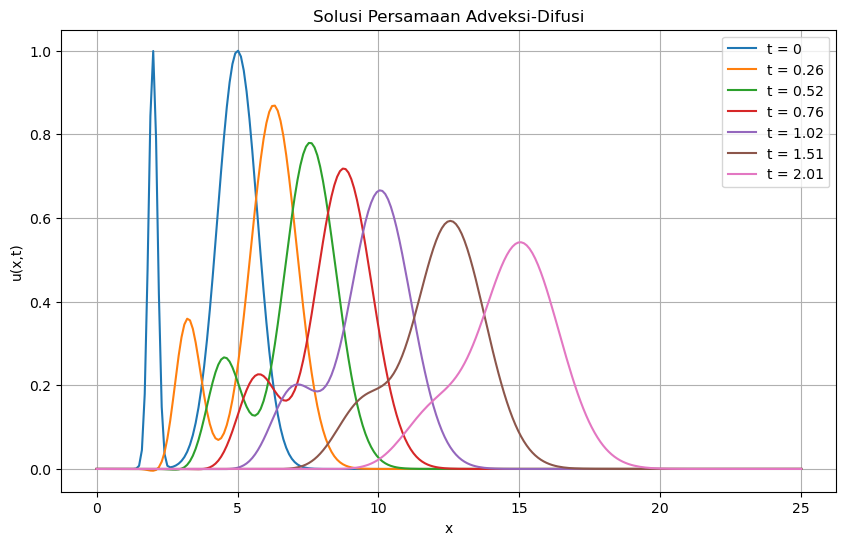

In [1]:
import numpy                         
import matplotlib.pyplot as plt     
import scipy.sparse as sparse        
import scipy.sparse.linalg as linalg 

# Fungsi Crank-Nicolson (Difusi)
def CN_step(delta_x, delta_t, U_0, kappa=1.0):
    m = U_0.shape[0]                         # jumlah titik grid
    r = 0.5 * kappa * delta_t / delta_x**2   # parameter skema CN
    
    e = numpy.ones(m + 1) * r                # vektor bantu
    D2 = sparse.spdiags([e, -2.0 * e, e], [-1, 0, 1], m, m).tolil()  # matriks turunan kedua
    
    D2[0, -1] = r    # kondisi batas periodik (kiri ke kanan)
    D2[-1, 0] = r    # kondisi batas periodik (kanan ke kiri)
    
    I = sparse.eye(m)             # matriks identitas
    A1 = (I - D2).tocsr()         # matriks sisi kiri (implisit)
    A2 = (I + D2).tocsr()         # matriks sisi kanan
    
    b = A2.dot(U_0.copy())        # membentuk ruas kanan
    
    return linalg.spsolve(A1, b)  # menyelesaikan sistem linear

# Fungsi Lax-Wendroff (Adveksi)
def LW_step(delta_x, delta_t, U_0, a):
    U = numpy.empty(U_0.shape)    # array solusi baru
    
    # titik pertama (pakai kondisi periodik)
    U[0] = U_0[0] - a * delta_t/(2*delta_x)*(U_0[1]-U_0[-1]) \
                     + a*delta_t**2/(2*delta_x**2)*(U_0[1]-2*U_0[0]+U_0[-1])
    
    # titik tengah
    U[1:-1] = U_0[1:-1] - a * delta_t/(2*delta_x)*(U_0[2:]-U_0[:-2]) \
                              + a*delta_t**2/(2*delta_x**2)*(U_0[2:]-2*U_0[1:-1]+U_0[:-2])
    
    # titik terakhir (kondisi periodik)
    U[-1] = U_0[-1] - a * delta_t/(2*delta_x)*(U_0[0]-U_0[-2]) \
                       + a*delta_t**2/(2*delta_x**2)*(U_0[0]-2*U_0[-1]+U_0[-2])
    
    return U                      # mengembalikan hasil adveksi

# Parameter Masalah
L = 25.0          # panjang domain
a = 5.0           # kecepatan adveksi
kappa = 0.5       # koefisien difusi

m = 250                           # jumlah grid
x = numpy.linspace(0.0, L, m)     # pembagian domain
delta_x = L / (m + 1)             # jarak antar titik

delta_t = delta_x / a             # langkah waktu (CFL condition)

# Kondisi Awal
U = numpy.exp(-20*(x-2)**2) + numpy.exp(-(x-5)**2)  # dua gelombang Gaussian

# Waktu Simulasi
t = 0.0
output_times = [0.25, 0.5, 0.75, 1.0, 1.5, 2.0]  # waktu yang ingin ditampilkan

# Plot Awal
plt.figure(figsize=(10,6))      # ukuran grafik
plt.plot(x, U, label="t = 0")   # kondisi awal

# Iterasi Waktu (Godunov Splitting)
for t_final in output_times:     # loop untuk tiap waktu output
    while t < t_final:           # iterasi sampai waktu target
        
        U = CN_step(delta_x, delta_t, U, kappa)  # langkah difusi (implisit)
        U = LW_step(delta_x, delta_t, U, a)      # langkah adveksi (eksplisit)
        
        t += delta_t             # update waktu
    
    plt.plot(x, U, label=f"t = {round(t,2)}")  # plot hasil di waktu tertentu

# Tampilkan Grafik
plt.legend()                    # menampilkan legenda
plt.xlabel("x")                 # label sumbu x
plt.ylabel("u(x,t)")            # label sumbu y
plt.title("Solusi Persamaan Adveksi-Difusi")  # judul
plt.grid()                      # grid
plt.show()                      # tampilkan grafik